# Character Identification CNN Model
Ze Hao version

### Import Modules

This notebook uses PyTorch for the processing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import cv2
import os

from torchvision.transforms import v2

In [2]:
train_data_dir = "./chars_train_data_augmented"
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

### Object Classes
Set up the mapping of each character label to the label ID

In [3]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

36



### Setting up the Dataset and Train + Validation Dataloaders

For more information about creating custom dataset and using dataloader, check out [this tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).


In [4]:
class CharDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir="", is_train=True):
        self.data_dir = data_dir
        
        # Get all PNG files
        self.image_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.png') or f.lower().endswith('.PNG')]
        if len(self.image_files) == 0:
            raise FileNotFoundError(f"No .png files found in {data_dir}")

        # Extract labels from filenames (everything before the first '_')
        self.labels = [f.split('_')[0] for f in self.image_files]
        
        self.is_train = is_train
        
    def __len__(self):
        return len(self.image_files) # Number of samples in dataset
        
    def __getitem__(self, index): # Defines what happens when a new sample is gotten from dataset
        fname = self.image_files[index]
        label_str = self.labels[index]
        label_idx = char_classes[label_str]

        img_path = os.path.join(self.data_dir, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Cannot read image {img_path}")

        # Preprocess img with cv2 resize if incorrect size
        if img.shape[0] != 42 or img.shape[1] != 42:
            img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)

        # Normalize to [0,1] and convert to float32
        img = img.astype('float32') / 255.0
        # Add channel dimension (1, 42, 42)
        img = np.expand_dims(img, axis=0)
        # Convert to torch tensors
        img_tensor = torch.tensor(img, dtype=torch.float32)

        return fname, img_tensor, label_idx


In [5]:
from torch.utils.data import DataLoader, random_split

validation_set_fraction = 0.1 # Default is 0.1 of data as validation set

# Make dataset
dataset = CharDataset(data_dir=train_data_dir, is_train=True)

# Split 90% train, 10% val datasets
val_size = int(0.1 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

### Inspect and visualize your data

It is recommended to inspect some samples of your data through visualization

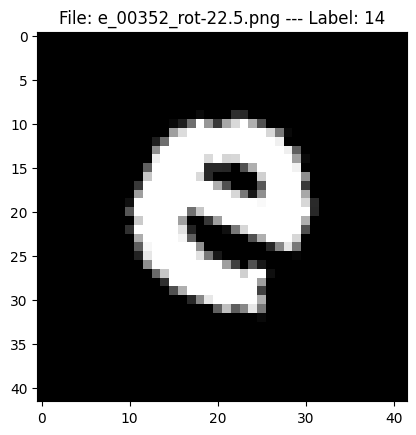

In [6]:
img_id, X_transformed, y = train_dataset[0]

plt.imshow(X_transformed[0], cmap='gray')
plt.title(f'File: {img_id} --- Label: {y}')
plt.show()


### Setting up the GPU

Kaggle provides GPU to speed up neural network evaluations. To activate it, click on Accelerator and select GPU. Note that there is a usage quota, so use it wisely.


In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0



# Setting up your neural network model

As mentioned in the Getting Started section, you should check out this tutorial. Although not covered in lectures, you should consider learning and using these:

- Convolutional neural network layers ([``torch.nn.Conv2D``](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html))
- Maxpool layers ([``torch.nn.MaxPool2d``](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html))
- Adam optimizer ([``torch.nn.Adam``](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
- [Pre-trained models](https://pytorch.org/vision/stable/models.html)
- [Loss functions](https://pytorch.org/docs/stable/nn.html#loss-functions)



In [8]:
import torch.nn as nn
import torch.nn.functional as F

# Add your Neural Network here (if using NN)

class Model(nn.Module):
    # Convenience function for getting the no. of parameters after convolution
    def get_num_features_after_conv(self, shape):
        # Pass a dummy input through the conv layers
        x = torch.zeros(1, *shape)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        return x.numel()  # total number of features after flattening
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 128, 3)
        
        self.fc1 = nn.Linear(self.get_num_features_after_conv((42, 42)), 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Conv layer -> Relu -> Maxpool
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Model()
net.to(device)

def count_params(net, trainable=False):
    if trainable:
        count = sum(p.numel() for p in net.parameters() if p.requires_grad)
    else:
        count = sum(p.numel() for p in net.parameters())
    return count

print(F'Network has {count_params(net, trainable=False)} parameters in total')
print(F'Network has {count_params(net, trainable=True)} trainable parameters in total')

Network has 179428 parameters in total
Network has 179428 trainable parameters in total


# Training the Model

### Early stopping mechanism
Do not continue training if validation loss has not decreased for n epochs (prevents overfitting)

Mechanism referenced from: https://medium.com/biased-algorithms/a-practical-guide-to-implementing-early-stopping-in-pytorch-for-model-training-99a7cbd46e9d

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        """
        Stops training if val_loss doesn't improve after `patience` epochs
        min_delta = minimum change to qualify as an improvement
        """
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.epochs_without_improvement = 0
        self.stop_training = False
    
    def check_early_stopping(self, val_loss):
        if self.best_loss is None or val_loss < (self.best_loss - self.delta):
            self.best_loss = val_loss
            self.epochs_without_improvement = 0
        else:
            self.epochs_without_improvement += 1
            if self.epochs_without_improvement >= self.patience:
                self.stop_training = True
                print("Stopping early as no validation loss improvement has been observed.")

# Initialize early stopping class
early_stopping = EarlyStopping(patience=3, delta=0)

### Training

Epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████| 468/468 [00:24<00:00, 19.48it/s]


Epoch [1/5] - Train Loss: 0.3621 - Val Loss: 0.4446


Epoch 2/5: 100%|█████████████████████████████████████████████████████████████████████| 468/468 [00:25<00:00, 18.06it/s]


Epoch [2/5] - Train Loss: 0.3337 - Val Loss: 0.4441


Epoch 3/5: 100%|█████████████████████████████████████████████████████████████████████| 468/468 [00:26<00:00, 17.88it/s]


Epoch [3/5] - Train Loss: 0.3216 - Val Loss: 0.4506


Epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████| 468/468 [00:25<00:00, 18.59it/s]


Epoch [4/5] - Train Loss: 0.3061 - Val Loss: 0.4379


Epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████| 468/468 [00:25<00:00, 18.63it/s]


Epoch [5/5] - Train Loss: 0.2906 - Val Loss: 0.4355


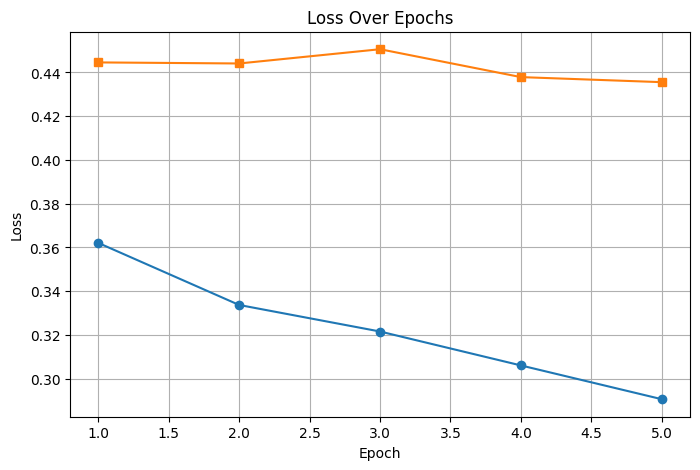

In [14]:
from tqdm import tqdm # for a progress bar

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
num_epochs = 5

epoch_train_losses = []  # store loss for each epoch
epoch_val_losses = []

for epoch in range(num_epochs):
    net.train()  # set model to training mode
    running_loss = 0.0 
    # Running loss sums the loss values for each mini-batch, to later compute the average loss per epoch

    # Training
    for img_id, X_transformed, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        X_transformed, y = X_transformed.to(device, non_blocking=True), y.to(device, non_blocking=True)

        # Forward pass
        y_pred_logits = net(X_transformed)
        loss = criterion(y_pred_logits, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    val_loss = 0.0
    net.eval()
    with torch.no_grad():
        for img_id, X_transformed, y in val_dataloader:
            X_transformed, y = X_transformed.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
             # Forward pass
            y_pred_logits = net(X_transformed)
            loss = criterion(y_pred_logits, y)
            
            val_loss += loss.item()

    avg_train_loss = running_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    epoch_train_losses.append(avg_train_loss)
    epoch_val_losses.append(avg_val_loss)

    # Early stopping?
    early_stopping.check_early_stopping(avg_val_loss)
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch}")
        break

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_train_losses) + 1), epoch_train_losses, marker='o', label='Train Loss')
plt.plot(range(1, len(epoch_val_losses) + 1), epoch_val_losses, marker='s', label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Making predictions
Naive: Simply take the highest logit and take it as prediction.

In [15]:
def predict(y_pred_logits): 
    # Take the index of the highest logit for each sample
    y_pred = torch.argmax(y_pred_logits, dim=1) # Note: returns a tensor
    return y_pred

### Allowance for similar characters
According to prof, captcha often has allowance for similar characters being mistaken. So we can have a metric for this as well.

In [27]:
def is_char_correct_with_allowance(input, truth):
    similars = [["o", "0"], 
               ["1", "l", "i"],
               ["9", "q"]]
    for group in similars:
        if truth in group:
            return input in group

    return input == truth

### Evaluate on Validation set

In [28]:
net.eval()  # set model to evaluation mode (disables dropout/batchnorm)
correct = 0
correct_with_allowance = 0
total = 0


with torch.no_grad():
    for img_id, X_transformed, y in tqdm(val_dataloader):
        X_transformed = X_transformed.to(device)
        y = y.to(device)

        # Forward pass
        outputs = net(X_transformed)
        
        # Predicted class = index of max logit
        predicted = predict(outputs)

        # Map predicted indices and ground truth indices to characters
        predicted_chars = [inv_char_classes[idx.item()] for idx in predicted]
        true_chars = [inv_char_classes[idx.item()] for idx in y]
        
         # Compare with allowance
        for pc, tc in zip(predicted_chars, true_chars):
            if pc == tc:
                correct += 1
            if is_char_correct_with_allowance(pc, tc):
                correct_with_allowance += 1
            total += 1
        

accuracy = 100 * correct / total
accuracy_with_allowance = 100 * correct_with_allowance / total
print(f'Total: {total}')
print(f'Correct: {correct}')
print(f'Correct with Allowance: {correct_with_allowance}')
print(f'Accuracy on Validation Data: {accuracy:.2f}%')
print(f'Accuracy on Validation Data with Allowance: {accuracy_with_allowance:.2f}%')

100%|██████████████████████████████████████████████████████████████████████████████████| 52/52 [00:04<00:00, 11.40it/s]

Total: 13289
Correct: 11451
Correct with Allowance: 11855
Accuracy on Validation Data: 86.17%
Accuracy on Validation Data with Allowance: 89.21%


### Inference on single sample

In [15]:
def predict_single_image(net, img_path, char_classes, show=True):
    # Load img
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")

    # Preprocess img with cv2 resize if incorrect size
    if img.shape[0] != 42 or img.shape[1] != 42:
        img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)

    # Normalize and convert to tensor
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)   # (1, 42, 42)
    img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, 42, 42)

    net.eval()
    with torch.no_grad():
        output = net(img_tensor)
        predicted_class = predict(output).item()

    # Map index back to character
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[predicted_class]
    
    if show:
        # Show original image
        plt.imshow(img[0], cmap='gray')
        plt.title(f"File: {img_path} --- Predicted: {predicted_label}")
        
    return predicted_label

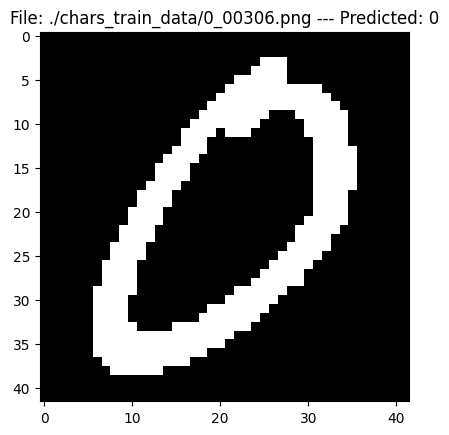

In [17]:
img_path = "./chars_train_data/0_00306.png"
pred = predict_single_image(net, img_path, char_classes, show=True)